# Tutorial_Zeus21_Basics — baseline vs corrected (par/perp eta) comparison

This notebook mirrors `Tutorial_Zeus21_Basics.ipynb` and runs the same scenarios twice:

- **Baseline**: `zeus21.cosmo_wrapper` / `zeus21.Power_Spectra` (original isotropic eta correlation).
- **Corrected (v2)**: `zeus21.cosmology_v2.cosmo_wrapper` / `zeus21.correlations_v2.Power_Spectra`, where the four `(1 - K * xiEta)**(3/2)` factors in `get_xi_Sum_2ExpEta` have been replaced by `((1 - K * xiEtapar)*(1 - K * xiEtaperp)**2)**(1/2)`, with `P_eta` split into `P_etapar` (integrand `6*(psi0+psi2)**2`) and `P_etaperp` (integrand `6*(psi0-psi2/2)**2`).

The correction only enters the Pop III + relative-velocities branch (`USE_POPIII=True` and `USE_RELATIVE_VELOCITIES=True`). With the tutorial's default flags, both pipelines should agree exactly, which we use as a sanity check.

In [1]:
## Make sure we import the LOCAL zeus21 (which has cosmology_v2/correlations_v2)
## instead of any older copy installed in site-packages.
import sys, os
_REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)

import zeus21
print('zeus21 loaded from:', zeus21.__file__)
from zeus21 import cosmology_v2, correlations_v2
from matplotlib import pyplot as plt
import numpy as np

from classy import Class
ClassCosmo = Class()
ClassCosmo.compute()

UserParams = zeus21.User_Parameters(precisionboost=1.2)

zeus21 loaded from: /Users/kamion/SCIENCE/Zeus21-2/zeus21/__init__.py


## Scenario A — tutorial defaults (no Pop III, no relative velocities)

Sanity check: with the eta correction inactive, baseline and corrected pipelines must agree to numerical precision.

In [2]:
omega_cdm = 0.12
epsilon_star = 0.15
ZMIN = 10.0
RSDMODE = 1

def run_pipeline(cosmo_wrapper, PowerSpectra_cls, *, USE_POPIII=False, USE_RELATIVE_VELOCITIES=False, L40_xray=3.0):
    """Run a full Zeus21 pipeline with either the baseline or the corrected modules."""
    CosmoParams_input = zeus21.Cosmo_Parameters_Input(
        omegac=omega_cdm,
        USE_RELATIVE_VELOCITIES=USE_RELATIVE_VELOCITIES,
    )
    CosmoParams, ClassyCosmo, CorrFClass, HMFintclass = cosmo_wrapper(UserParams, CosmoParams_input)
    AstroParams = zeus21.Astro_Parameters(UserParams, CosmoParams, epsstar=epsilon_star, USE_POPIII=USE_POPIII, L40_xray=L40_xray)
    Coeff = zeus21.get_T21_coefficients(UserParams, CosmoParams, ClassyCosmo, AstroParams, HMFintclass, zmin=ZMIN)
    PS21 = PowerSpectra_cls(UserParams, CosmoParams, AstroParams, ClassyCosmo, CorrFClass, Coeff, RSD_MODE=RSDMODE)
    return CosmoParams, AstroParams, Coeff, PS21

# Baseline (original modules)
_, _, Coeff_base, PS21_base = run_pipeline(zeus21.cosmo_wrapper, zeus21.Power_Spectra)

# Corrected (v2 modules)
_, _, Coeff_v2, PS21_v2 = run_pipeline(cosmology_v2.cosmo_wrapper, correlations_v2.Power_Spectra)

zlist = Coeff_base.zintegral
klist = PS21_base.klist_PS
print('Scenario A pipelines complete.')

Scenario A pipelines complete.


In [3]:
# Sanity equivalence check (correction is a no-op without USE_RELATIVE_VELOCITIES + USE_POPIII)
print('max |T21avg diff|         :', np.max(np.abs(Coeff_base.T21avg - Coeff_v2.T21avg)))
print('max |Tk_avg diff|         :', np.max(np.abs(Coeff_base.Tk_avg - Coeff_v2.Tk_avg)))
print('max |1/Ts_avg diff|       :', np.max(np.abs(Coeff_base._invTs_avg - Coeff_v2._invTs_avg)))
print('max |Deltasq_T21 diff|    :', np.max(np.abs(PS21_base.Deltasq_T21 - PS21_v2.Deltasq_T21)))
print('max |Deltasq_T21_lin diff|:', np.max(np.abs(PS21_base.Deltasq_T21_lin - PS21_v2.Deltasq_T21_lin)))
assert np.allclose(Coeff_base.T21avg, Coeff_v2.T21avg, rtol=1e-12, atol=1e-12)
assert np.allclose(PS21_base.Deltasq_T21, PS21_v2.Deltasq_T21, rtol=1e-12, atol=1e-12)
print('OK: baseline and corrected pipelines agree exactly (correction inactive).')

max |T21avg diff|         : 0.0
max |Tk_avg diff|         : 0.0
max |1/Ts_avg diff|       : 0.0
max |Deltasq_T21 diff|    : 0.0
max |Deltasq_T21_lin diff|: 0.0
OK: baseline and corrected pipelines agree exactly (correction inactive).


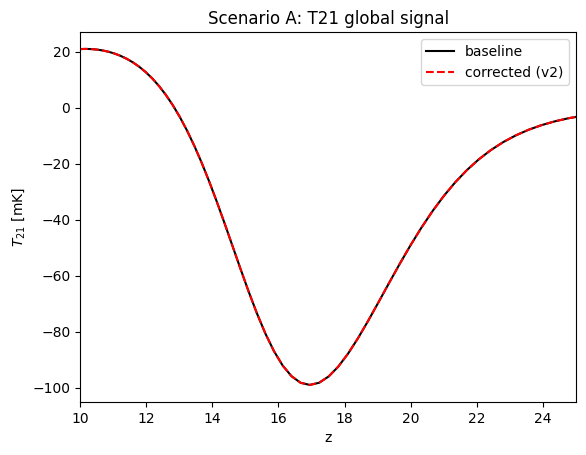

In [4]:
# Reproduce the tutorial's global signal plot (baseline vs corrected curves overlaid).
plt.plot(zlist, Coeff_base.T21avg, 'k',  label='baseline')
plt.plot(zlist, Coeff_v2.T21avg,   'r--', label='corrected (v2)')
plt.xlabel(r'z'); plt.ylabel(r'$T_{21}$ [mK]')
plt.xlim([10, 25]); plt.legend(); plt.title('Scenario A: T21 global signal')
plt.show()

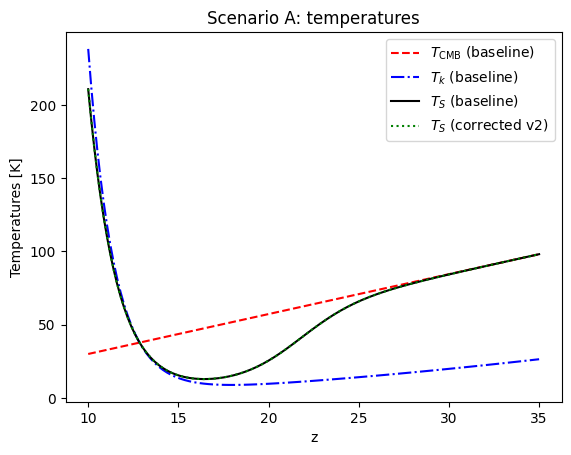

In [5]:
# Temperatures (CMB, Tk, Ts) baseline vs corrected.
plt.plot(zlist, Coeff_base.T_CMB, 'r--', label=r'$T_{\rm CMB}$ (baseline)')
plt.plot(zlist, Coeff_base.Tk_avg, 'b-.', label=r'$T_k$ (baseline)')
plt.plot(zlist, 1.0/Coeff_base._invTs_avg, 'k', label=r'$T_S$ (baseline)')
plt.plot(zlist, 1.0/Coeff_v2._invTs_avg, 'g:', label=r'$T_S$ (corrected v2)')
plt.xlabel(r'z'); plt.ylabel(r'Temperatures [K]')
plt.legend(); plt.title('Scenario A: temperatures')
plt.show()

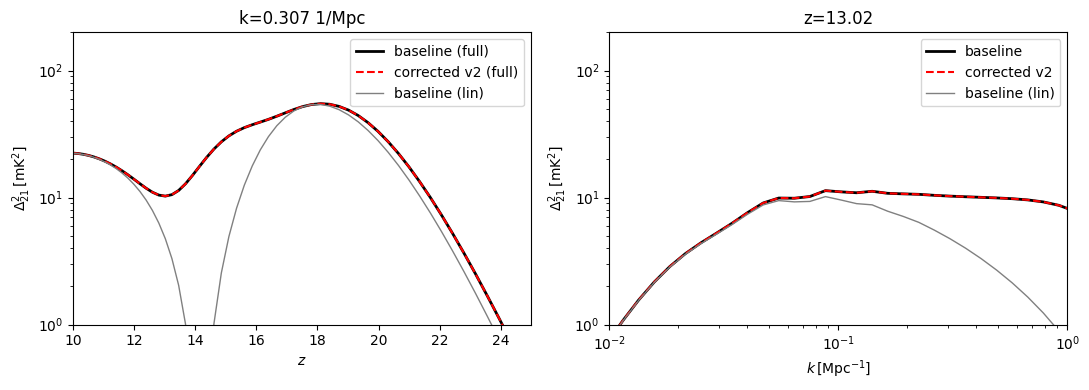

In [6]:
# Power spectrum vs z at fixed k (k~0.3 1/Mpc), and vs k at fixed z (z=13).
kchoose = 0.3
_ik = int(np.argmin(np.abs(klist - kchoose)))
zchoose = 13.0
_iz = int(np.argmin(np.abs(zlist - zchoose)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.semilogy(zlist, PS21_base.Deltasq_T21[:, _ik], 'k', lw=2.0, label='baseline (full)')
ax.semilogy(zlist, PS21_v2.Deltasq_T21[:, _ik],   'r--', lw=1.5, label='corrected v2 (full)')
ax.semilogy(zlist, PS21_base.Deltasq_T21_lin[:, _ik], color='gray', lw=1.0, label='baseline (lin)')
ax.set_xlabel(r'$z$'); ax.set_ylabel(r'$\Delta^2_{21}\,[{\rm mK}^2]$')
ax.set_xlim([10, 25]); ax.set_ylim([1, 200]); ax.legend(); ax.set_title(f'k={klist[_ik]:.3g} 1/Mpc')

ax = axes[1]
ax.loglog(klist, PS21_base.Deltasq_T21[_iz], 'k', lw=2.0, label='baseline')
ax.loglog(klist, PS21_v2.Deltasq_T21[_iz],   'r--', lw=1.5, label='corrected v2')
ax.loglog(klist, PS21_base.Deltasq_T21_lin[_iz], color='gray', lw=1.0, label='baseline (lin)')
ax.set_xlabel(r'$k\,[{\rm Mpc}^{-1}]$'); ax.set_ylabel(r'$\Delta^2_{21}\,[{\rm mK}^2]$')
ax.set_xlim([1e-2, 1]); ax.set_ylim([1, 200]); ax.legend(); ax.set_title(f'z={zlist[_iz]:.2f}')
plt.tight_layout(); plt.show()

## Scenario B — Pop III + relative velocities ENABLED

This is the regime where the par/perp eta correction in `get_xi_Sum_2ExpEta` actually changes results. Same astro otherwise as Scenario A; both pipelines run with `USE_POPIII=True` and `USE_RELATIVE_VELOCITIES=True`.

Each plot below overlays baseline vs corrected with a fractional-difference subpanel.

In [7]:
_, _, Coeff_base_B, PS21_base_B = run_pipeline(
    zeus21.cosmo_wrapper, zeus21.Power_Spectra,
    USE_POPIII=True, USE_RELATIVE_VELOCITIES=True,
)
_, _, Coeff_v2_B, PS21_v2_B = run_pipeline(
    cosmology_v2.cosmo_wrapper, correlations_v2.Power_Spectra,
    USE_POPIII=True, USE_RELATIVE_VELOCITIES=True,
)
zlist_B = Coeff_base_B.zintegral
klist_B = PS21_base_B.klist_PS
print('Scenario B pipelines complete.')

Scenario B pipelines complete.


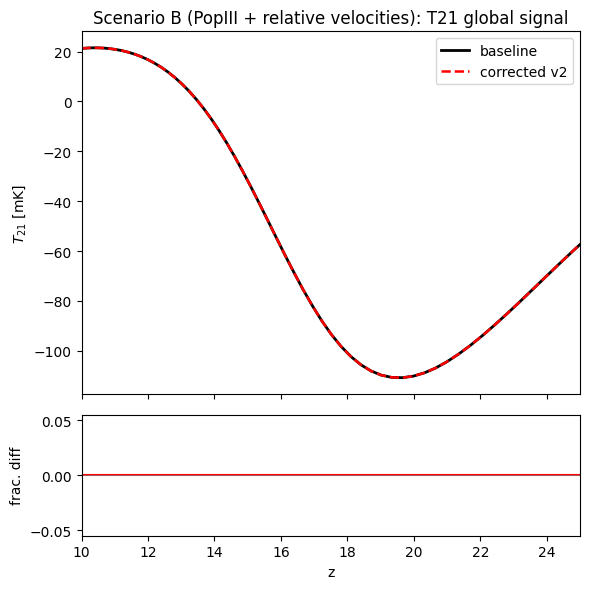

In [8]:
# Global signal: baseline vs corrected, with fractional-difference panel.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True, gridspec_kw={'height_ratios':[3,1]})
ax1.plot(zlist_B, Coeff_base_B.T21avg, 'k',  lw=2.0, label='baseline')
ax1.plot(zlist_B, Coeff_v2_B.T21avg,   'r--', lw=1.8, label='corrected v2')
ax1.set_ylabel(r'$T_{21}$ [mK]'); ax1.legend(); ax1.set_xlim([10, 25])
ax1.set_title('Scenario B (PopIII + relative velocities): T21 global signal')
denom = np.where(np.abs(Coeff_base_B.T21avg) > 1e-12, Coeff_base_B.T21avg, np.nan)
ax2.plot(zlist_B, (Coeff_v2_B.T21avg - Coeff_base_B.T21avg) / denom, 'r')
ax2.axhline(0, color='gray', lw=0.5)
ax2.set_ylabel('frac. diff'); ax2.set_xlabel(r'z')
plt.tight_layout(); plt.show()

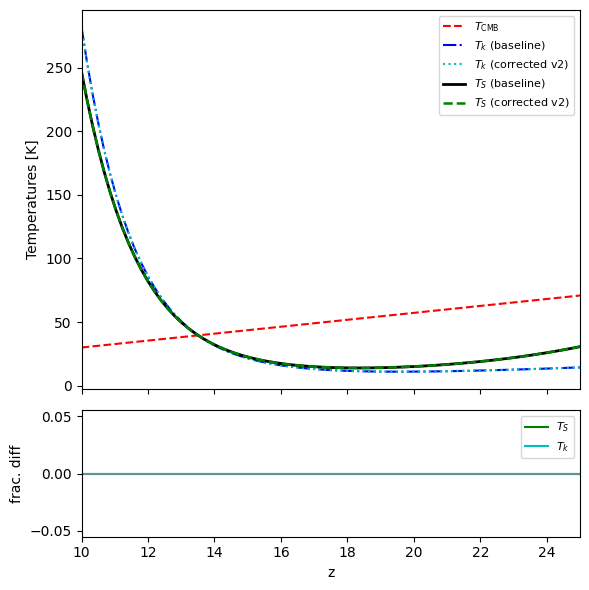

In [9]:
# Temperatures: spin temperature comparison, with fractional-difference panel.
Ts_base = 1.0/Coeff_base_B._invTs_avg
Ts_v2   = 1.0/Coeff_v2_B._invTs_avg
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True, gridspec_kw={'height_ratios':[3,1]})
ax1.plot(zlist_B, Coeff_base_B.T_CMB, 'r--', label=r'$T_{\rm CMB}$')
ax1.plot(zlist_B, Coeff_base_B.Tk_avg, 'b-.', label=r'$T_k$ (baseline)')
ax1.plot(zlist_B, Coeff_v2_B.Tk_avg,   'c:',  label=r'$T_k$ (corrected v2)')
ax1.plot(zlist_B, Ts_base, 'k',  lw=2.0, label=r'$T_S$ (baseline)')
ax1.plot(zlist_B, Ts_v2,   'g--', lw=1.8, label=r'$T_S$ (corrected v2)')
ax1.set_ylabel(r'Temperatures [K]'); ax1.legend(fontsize=8); ax1.set_xlim([10, 25])
ax2.plot(zlist_B, (Ts_v2 - Ts_base) / Ts_base, 'g', label=r'$T_S$')
ax2.plot(zlist_B, (Coeff_v2_B.Tk_avg - Coeff_base_B.Tk_avg) / Coeff_base_B.Tk_avg, 'c', label=r'$T_k$')
ax2.axhline(0, color='gray', lw=0.5)
ax2.set_ylabel('frac. diff'); ax2.set_xlabel(r'z'); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

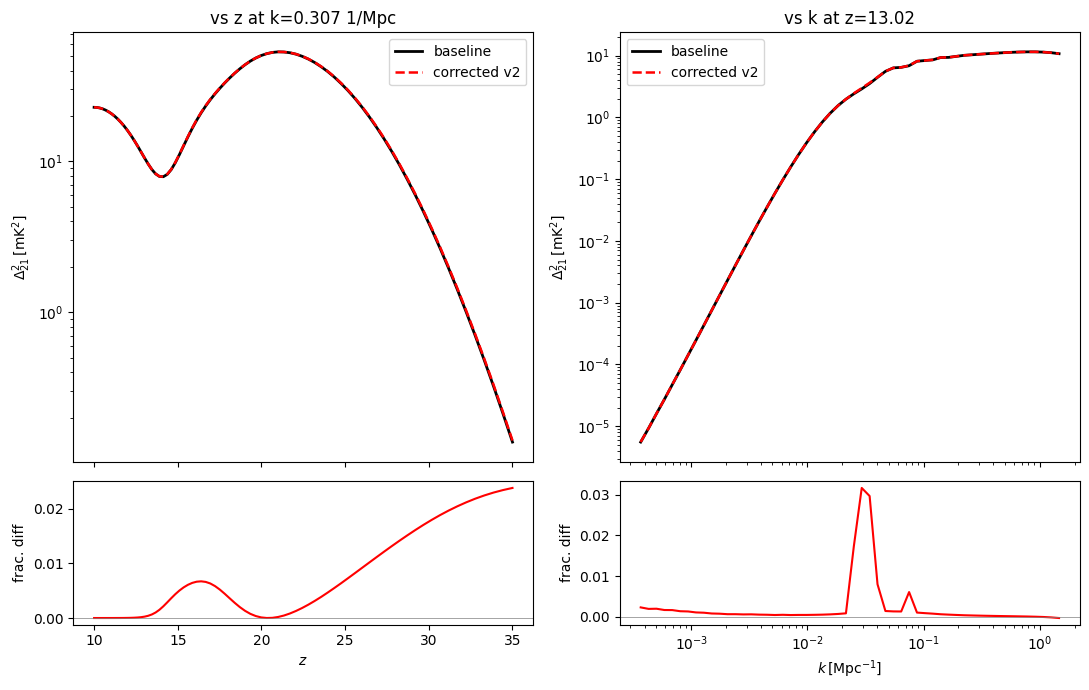

In [10]:
# 21-cm power spectrum: vs z at fixed k AND vs k at fixed z, each with fractional-difference subpanel.
_ikB = int(np.argmin(np.abs(klist_B - 0.3)))
_izB = int(np.argmin(np.abs(zlist_B - 13.0)))

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex='col', gridspec_kw={'height_ratios':[3,1]})

ax = axes[0, 0]
ax.semilogy(zlist_B, PS21_base_B.Deltasq_T21[:, _ikB], 'k',  lw=2.0, label='baseline')
ax.semilogy(zlist_B, PS21_v2_B.Deltasq_T21[:, _ikB],   'r--', lw=1.8, label='corrected v2')
ax.set_ylabel(r'$\Delta^2_{21}\,[{\rm mK}^2]$'); ax.legend()
ax.set_title(f'vs z at k={klist_B[_ikB]:.3g} 1/Mpc')
ax2 = axes[1, 0]
denom = PS21_base_B.Deltasq_T21[:, _ikB]
ax2.plot(zlist_B, (PS21_v2_B.Deltasq_T21[:, _ikB] - denom) / denom, 'r')
ax2.axhline(0, color='gray', lw=0.5); ax2.set_xlabel(r'$z$'); ax2.set_ylabel('frac. diff')

ax = axes[0, 1]
ax.loglog(klist_B, PS21_base_B.Deltasq_T21[_izB], 'k',  lw=2.0, label='baseline')
ax.loglog(klist_B, PS21_v2_B.Deltasq_T21[_izB],   'r--', lw=1.8, label='corrected v2')
ax.set_ylabel(r'$\Delta^2_{21}\,[{\rm mK}^2]$'); ax.legend()
ax.set_title(f'vs k at z={zlist_B[_izB]:.2f}')
ax2 = axes[1, 1]
denom = PS21_base_B.Deltasq_T21[_izB]
ax2.semilogx(klist_B, (PS21_v2_B.Deltasq_T21[_izB] - denom) / denom, 'r')
ax2.axhline(0, color='gray', lw=0.5); ax2.set_xlabel(r'$k\,[{\rm Mpc}^{-1}]$'); ax2.set_ylabel('frac. diff')

plt.tight_layout(); plt.show()

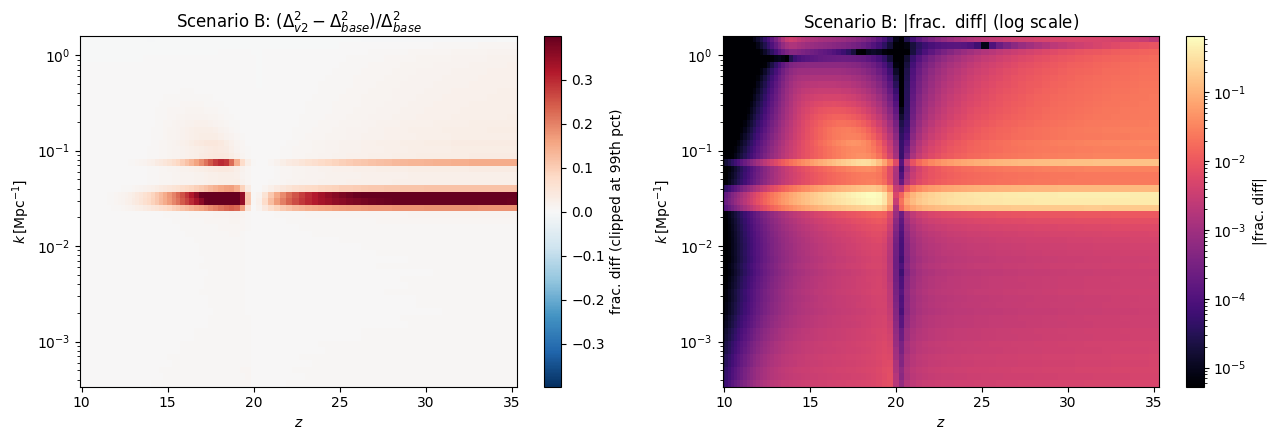

max |frac diff| = +0.652 at z=18.71, k=0.0343 1/Mpc
99th percentile |frac diff| = 0.398
median       |frac diff| = 2.905e-03


In [12]:
# 2D map of the fractional difference in Delta^2_{21}(z,k) for Scenario B,
# to show *where* in (z,k) the par/perp eta correction matters most.
fracdiff_B = (PS21_v2_B.Deltasq_T21 - PS21_base_B.Deltasq_T21) / np.where(
    np.abs(PS21_base_B.Deltasq_T21) > 1e-30, PS21_base_B.Deltasq_T21, np.nan
)

# Symmetric color scale clipped at the 99th percentile so a few outlier bins
# don't wash out the rest of the map.
vmax = np.nanpercentile(np.abs(fracdiff_B), 99)
vmax = float(max(vmax, 1e-3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Signed fractional difference
ax = axes[0]
pcm = ax.pcolormesh(zlist_B, klist_B, fracdiff_B.T, cmap='RdBu_r',
                    vmin=-vmax, vmax=vmax, shading='auto')
ax.set_yscale('log')
ax.set_xlabel(r'$z$'); ax.set_ylabel(r'$k\,[{\rm Mpc}^{-1}]$')
ax.set_title(r'Scenario B: $(\Delta^2_{v2}-\Delta^2_{base})/\Delta^2_{base}$')
cb = fig.colorbar(pcm, ax=ax); cb.set_label('frac. diff (clipped at 99th pct)')

# |frac diff| on log color scale, to highlight the largest-difference bins
ax = axes[1]
absfd = np.abs(fracdiff_B).T
absfd_plot = np.where(absfd > 0, absfd, np.nan)
from matplotlib.colors import LogNorm
vmin_log = max(np.nanpercentile(absfd_plot, 5), 1e-6)
vmax_log = float(np.nanmax(absfd_plot))
pcm = ax.pcolormesh(zlist_B, klist_B, absfd_plot, cmap='magma',
                    norm=LogNorm(vmin=vmin_log, vmax=vmax_log), shading='auto')
ax.set_yscale('log')
ax.set_xlabel(r'$z$'); ax.set_ylabel(r'$k\,[{\rm Mpc}^{-1}]$')
ax.set_title(r'Scenario B: $|{\rm frac.\ diff}|$ (log scale)')
cb = fig.colorbar(pcm, ax=ax); cb.set_label('|frac. diff|')

plt.tight_layout(); plt.show()

# Report the worst (z,k) bins so the numerical claim is anchored to a location.
flat_idx = np.nanargmax(np.abs(fracdiff_B))
iz_max, ik_max = np.unravel_index(flat_idx, fracdiff_B.shape)
print(f'max |frac diff| = {fracdiff_B[iz_max, ik_max]:+.3f} '
      f'at z={zlist_B[iz_max]:.2f}, k={klist_B[ik_max]:.3g} 1/Mpc')
print(f'99th percentile |frac diff| = {np.nanpercentile(np.abs(fracdiff_B), 99):.3f}')
print(f'median       |frac diff| = {np.nanmedian(np.abs(fracdiff_B)):.3e}')


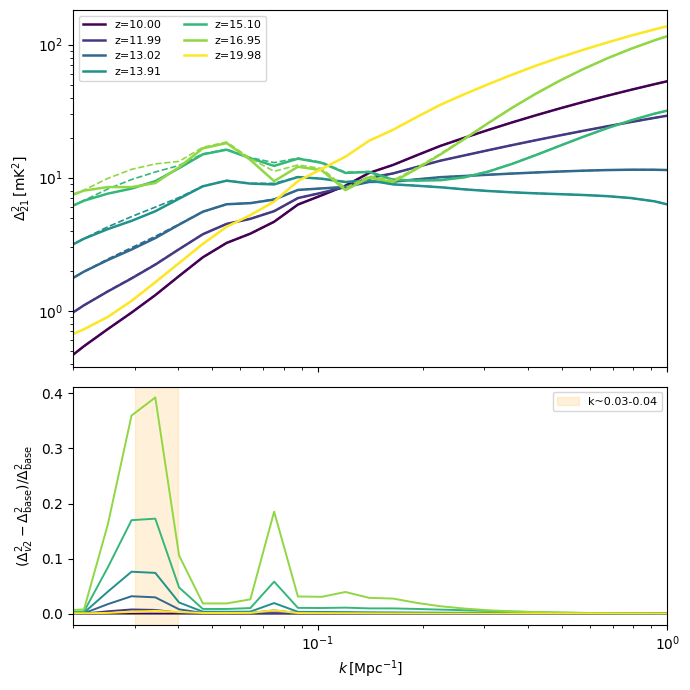

In [19]:
# Delta^2_{21}(k) at several redshifts (Scenario B), to expose the
# baseline null/feature near k~0.03-0.04 1/Mpc that drives the large
# fractional differences in the (z,k) map above.
z_targets = [10.0, 12.0, 13.0, 14.0, 15.0, 17.0, 20.0]
iz_list = [int(np.argmin(np.abs(zlist_B - zt))) for zt in z_targets]

KMIN, KMAX = 0.02, 1.0
kmask = (klist_B >= KMIN) & (klist_B <= KMAX)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                               gridspec_kw={'height_ratios': [3, 2]})

cmap = plt.get_cmap('viridis')
ymin_top = np.inf; ymax_top = -np.inf
ymin_bot = np.inf; ymax_bot = -np.inf
for j, iz in enumerate(iz_list):
    color = cmap(j / max(len(iz_list) - 1, 1))
    label = f'z={zlist_B[iz]:.2f}'
    base_row = PS21_base_B.Deltasq_T21[iz]
    v2_row   = PS21_v2_B.Deltasq_T21[iz]
    ax1.loglog(klist_B, base_row, color=color, lw=1.8, label=label)
    ax1.loglog(klist_B, v2_row,   color=color, lw=1.2, ls='--')

    fd = (v2_row - base_row) / np.where(np.abs(base_row) > 1e-30, base_row, np.nan)
    ax2.semilogx(klist_B, fd, color=color, lw=1.4)

    # accumulate plot-window data ranges
    pos_window = np.concatenate([base_row[kmask], v2_row[kmask]])
    pos_window = pos_window[np.isfinite(pos_window) & (pos_window > 0)]
    if pos_window.size:
        ymin_top = min(ymin_top, pos_window.min())
        ymax_top = max(ymax_top, pos_window.max())
    fd_window = fd[kmask]
    fd_window = fd_window[np.isfinite(fd_window)]
    if fd_window.size:
        ymin_bot = min(ymin_bot, fd_window.min())
        ymax_bot = max(ymax_bot, fd_window.max())

ax1.set_ylabel(r'$\Delta^2_{21}\,[{\rm mK}^2]$')
# ax1.set_title(r'Scenario B: $\Delta^2_{21}(k)$ at several $z$ — solid: baseline, dashed: corrected v2')
ax1.legend(fontsize=8, ncol=2)
ax1.set_xlim([KMIN, KMAX])
if np.isfinite(ymin_top) and np.isfinite(ymax_top):
    ax1.set_ylim([ymin_top * 0.7, ymax_top * 1.4])

ax2.axhline(0, color='gray', lw=0.5)
ax2.axvspan(0.03, 0.04, color='orange', alpha=0.15, label='k~0.03-0.04')
ax2.set_xlabel(r'$k\,[{\rm Mpc}^{-1}]$')
ax2.set_ylabel(r'$(\Delta^2_{v2}-\Delta^2_{\rm base})/\Delta^2_{\rm base}$')
ax2.legend(fontsize=8, loc='best')
if np.isfinite(ymin_bot) and np.isfinite(ymax_bot):
    pad = 0.05 * max(abs(ymin_bot), abs(ymax_bot), 1e-3)
    ax2.set_ylim([ymin_bot - pad, ymax_bot + pad])

plt.tight_layout(); plt.show()


using z = 15.0997 (target 15.1)
reconstruction check (max rel err): 6.439214569558949e-16

Top 6 terms by |contribution| in [0.01,0.1] 1/Mpc, baseline:
  Tx-Tx          max|contrib| = 30.16
  2*d-Tx         max|contrib| = 18.38
  d-d            max|contrib| = 3.402
  2*xa-Tx        max|contrib| = 1.878
  2*d-xa         max|contrib| = 0.5665
  xa-xa          max|contrib| = 0.02925


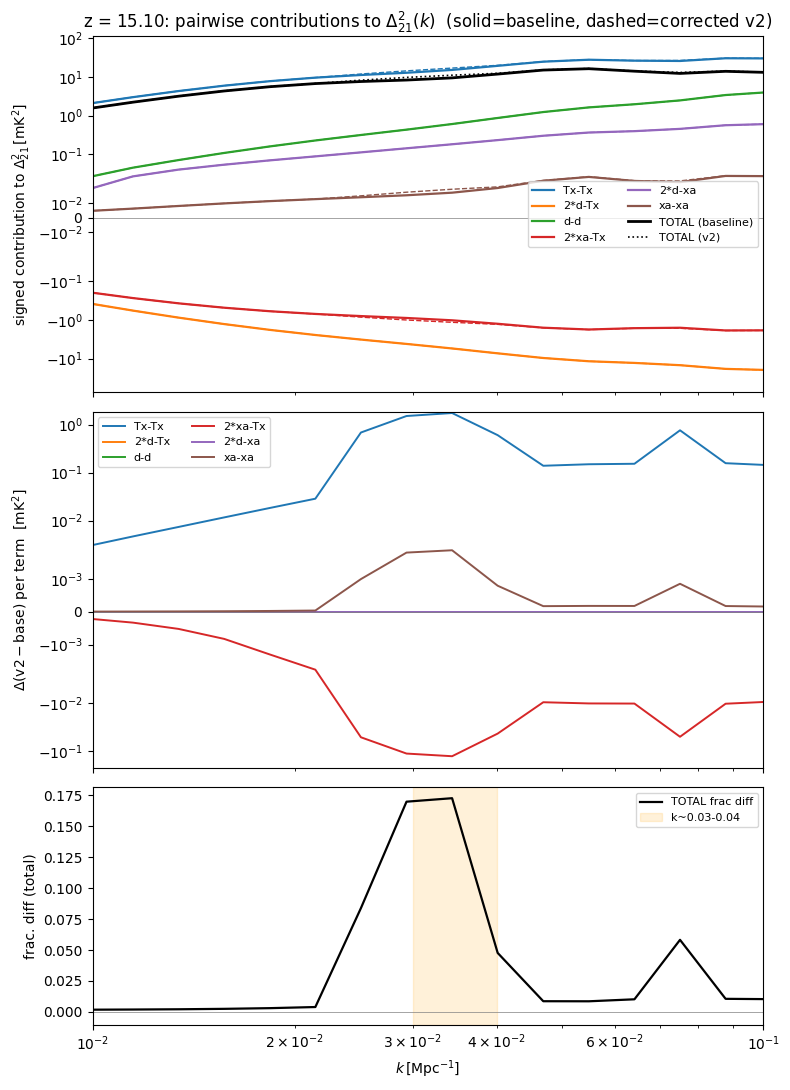


Worst |frac diff| in window at k = 0.03434 1/Mpc
  TOTAL  base=+9.413  v2=+11.04  frac diff=+0.173
  Pairwise contributions at this k (baseline vs v2, sorted by |base|):
    Tx-Tx     base=+15.1  v2=+16.85  delta=+1.751
    d-Tx      base=-5.469  v2=-5.469  delta=+0
    xa-Tx     base=-1.029  v2=-1.158  delta=-0.1298
    d-d       base=+0.6081  v2=+0.6081  delta=+0
    d-xa      base=+0.183  v2=+0.183  delta=+0
    xa-xa     base=+0.01754  v2=+0.01995  delta=+0.002405
    d-xion    base=+0  v2=+0  delta=+0
    xa-xion   base=+0  v2=+0  delta=+0
    Tx-xion   base=-0  v2=-0  delta=+0
    xion-xion  base=+0  v2=+0  delta=+0


In [16]:
# Decompose Delta^2_T21(k) at z~15.10 into pairwise contributions (Scenario B).
#
# In Power_Spectra, the total is built as
#   Delta^2_T21(k,z) = T21avg(z)^2 * sum_{i,j} beta_i(z) beta_j(z) * Delta^2_{ij}(k,z)
# with i,j in {d, x_a, T_x, x_ion} and the cross terms Delta^2_{ij} (symmetric).
#
# Plot every signed term beta_i*beta_j*Delta^2_{ij}*T21avg^2 vs k at the chosen z,
# for baseline and for corrected v2, plus the per-term difference. If two large terms
# of opposite sign nearly cancel near k~0.03-0.04, even a few-% correction on one of
# them shows up as a large *fractional* change in the total.

z_target = 15.10
iz_dec = int(np.argmin(np.abs(zlist_B - z_target)))
print(f'using z = {zlist_B[iz_dec]:.4f} (target {z_target})')

KMIN, KMAX = 0.01, 0.1
kmask = (klist_B >= KMIN) & (klist_B <= KMAX)

labels = ['d', 'xa', 'Tx', 'xion']

def term_contributions(PS):
    """Return dict {(i,j): beta_i*beta_j*Delta^2_{ij}(k) at iz_dec * T21avg^2}.
    Uses the same _allbetas, _allcorrs arrays Power_Spectra builds internally."""
    betas  = PS._allbetas[:, iz_dec]                           # shape (4,)
    corrs  = PS._allcorrs[:, :, iz_dec, :]                     # shape (4,4,Nk)
    # T21avg is the same in baseline & v2 (does not depend on eta correction)
    T21avg = Coeff_base_B.T21avg[iz_dec]
    out = {}
    for i in range(4):
        for j in range(4):
            out[(i, j)] = betas[i] * betas[j] * corrs[i, j] * T21avg**2
    return out

terms_base = term_contributions(PS21_base_B)
terms_v2   = term_contributions(PS21_v2_B)

# Sanity: sum of all 16 terms should reproduce Delta^2_T21
tot_base = sum(terms_base.values())
tot_v2   = sum(terms_v2.values())
print('reconstruction check (max rel err):',
      np.nanmax(np.abs(tot_base - PS21_base_B.Deltasq_T21[iz_dec]) /
                np.abs(PS21_base_B.Deltasq_T21[iz_dec])))

# Rank pairwise terms by max |contribution| over the k window of interest.
def rank_terms(terms):
    rows = []
    for (i, j), arr in terms.items():
        if i > j:
            continue  # symmetric, fold off-diagonals into i<j with factor 2
        contrib = arr if i == j else 2.0 * arr
        rows.append(((i, j), contrib, np.nanmax(np.abs(contrib[kmask]))))
    rows.sort(key=lambda r: -r[2])
    return rows

ranked_base = rank_terms(terms_base)
print('\nTop 6 terms by |contribution| in [0.01,0.1] 1/Mpc, baseline:')
for (i, j), arr, mx in ranked_base[:6]:
    name = f'{labels[i]}-{labels[j]}' if i == j else f'2*{labels[i]}-{labels[j]}'
    print(f'  {name:<14s} max|contrib| = {mx:.4g}')

# --- Plot: signed contributions vs k for top-6 terms, baseline (solid) vs v2 (dashed)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 11), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 3, 2]})
cmap = plt.get_cmap('tab10')

top_pairs = [pair for pair, _, _ in ranked_base[:6]]
for n, (i, j) in enumerate(top_pairs):
    base_arr = terms_base[(i, j)] if i == j else 2.0 * terms_base[(i, j)]
    v2_arr   = terms_v2[(i, j)]   if i == j else 2.0 * terms_v2[(i, j)]
    name = f'{labels[i]}-{labels[j]}' if i == j else f'2*{labels[i]}-{labels[j]}'
    color = cmap(n)
    ax1.plot(klist_B, base_arr, color=color, lw=1.6, label=name)
    ax1.plot(klist_B, v2_arr,   color=color, lw=1.0, ls='--')
    # absolute change per term
    ax2.plot(klist_B, v2_arr - base_arr, color=color, lw=1.4, label=name)

# total + baseline-v2 difference for context
ax1.plot(klist_B, tot_base, color='k', lw=2.0, label='TOTAL (baseline)')
ax1.plot(klist_B, tot_v2,   color='k', lw=1.2, ls=':', label='TOTAL (v2)')

# Symmetric log scale so we can see signs and magnitudes together.
top_max = np.nanmax(np.abs([terms_base[p][kmask] if p[0]==p[1] else 2*terms_base[p][kmask] for p in top_pairs]))
linthr = max(top_max * 1e-3, 1e-3)
ax1.set_yscale('symlog', linthresh=linthr)
ax1.axhline(0, color='gray', lw=0.5)
ax1.set_xscale('log'); ax1.set_xlim([KMIN, KMAX])
ax1.set_ylabel(r'signed contribution to $\Delta^2_{21}\,[{\rm mK}^2]$')
ax1.set_title(f'z = {zlist_B[iz_dec]:.2f}: pairwise contributions to $\\Delta^2_{{21}}(k)$  '
              f'(solid=baseline, dashed=corrected v2)')
ax1.legend(fontsize=8, ncol=2, loc='best')

# absolute change per term
ax2.axhline(0, color='gray', lw=0.5)
ax2.set_yscale('symlog', linthresh=max(np.nanmax(np.abs(tot_v2 - tot_base)) * 1e-3, 1e-4))
ax2.set_ylabel(r'$\Delta(\rm v2-base)$ per term  $[{\rm mK}^2]$')
ax2.legend(fontsize=8, ncol=2)

# fractional change in TOTAL, alongside the dominant terms' magnitudes for reference
denom = np.where(np.abs(tot_base) > 1e-30, tot_base, np.nan)
ax3.semilogx(klist_B, (tot_v2 - tot_base) / denom, 'k', lw=1.6, label='TOTAL frac diff')
ax3.axhline(0, color='gray', lw=0.5)
ax3.axvspan(0.03, 0.04, color='orange', alpha=0.15, label='k~0.03-0.04')
ax3.set_xlabel(r'$k\,[{\rm Mpc}^{-1}]$'); ax3.set_ylabel('frac. diff (total)')
ax3.legend(fontsize=8)

plt.tight_layout(); plt.show()

# Also: at the worst k bin, dump per-term contributions side by side so you can
# see by eye whether two large terms are nearly cancelling.
ik_worst = int(np.nanargmax(np.abs((tot_v2 - tot_base) / denom)[kmask]))
ik_worst_global = np.where(kmask)[0][ik_worst]
print(f'\nWorst |frac diff| in window at k = {klist_B[ik_worst_global]:.4g} 1/Mpc')
print(f'  TOTAL  base={tot_base[ik_worst_global]:+.4g}  v2={tot_v2[ik_worst_global]:+.4g}  '
      f'frac diff={(tot_v2[ik_worst_global]-tot_base[ik_worst_global])/tot_base[ik_worst_global]:+.3f}')
print('  Pairwise contributions at this k (baseline vs v2, sorted by |base|):')
rows = []
for (i, j) in [(a, b) for a in range(4) for b in range(a, 4)]:
    base_v = terms_base[(i, j)][ik_worst_global] * (1 if i == j else 2)
    v2_v   = terms_v2[(i, j)][ik_worst_global]   * (1 if i == j else 2)
    rows.append((f'{labels[i]}-{labels[j]}', base_v, v2_v, v2_v - base_v))
rows.sort(key=lambda r: -abs(r[1]))
for name, b, v, d in rows:
    print(f'    {name:<8s}  base={b:+.4g}  v2={v:+.4g}  delta={d:+.4g}')


In [17]:
# Runtime benchmark: baseline vs corrected (v2) pipeline.
#
# We time the *full* pipeline (run_pipeline) and also break it into the two
# stages where the v2 correction adds work:
#   - cosmo_wrapper: builds the eta correlation power spectra (v2 builds two
#     spectra, P_etapar and P_etaperp, instead of one)
#   - Power_Spectra: get_xi_Sum_2ExpEta now consumes two xiEta arrays
# Astro_Parameters and get_T21_coefficients are unchanged between the two,
# so any runtime gap should come from those two stages.

import time

def time_call(fn, *args, n_repeat=3, **kwargs):
    """Run fn n_repeat times, return (min, mean, last_result)."""
    times = []
    out = None
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        out = fn(*args, **kwargs)
        times.append(time.perf_counter() - t0)
    return min(times), sum(times) / len(times), out

def time_pipeline(cosmo_wrapper, PowerSpectra_cls, *, n_repeat=3,
                  USE_POPIII=True, USE_RELATIVE_VELOCITIES=True, L40_xray=3.0):
    cp_in = zeus21.Cosmo_Parameters_Input(
        omegac=omega_cdm, USE_RELATIVE_VELOCITIES=USE_RELATIVE_VELOCITIES,
    )
    # cosmo_wrapper
    t_cw_min, t_cw_mean, (CosmoParams, ClassyCosmo, CorrFClass, HMFintclass) = \
        time_call(cosmo_wrapper, UserParams, cp_in, n_repeat=n_repeat)
    AstroParams = zeus21.Astro_Parameters(
        UserParams, CosmoParams, epsstar=epsilon_star,
        USE_POPIII=USE_POPIII, L40_xray=L40_xray,
    )
    Coeff = zeus21.get_T21_coefficients(
        UserParams, CosmoParams, ClassyCosmo, AstroParams, HMFintclass, zmin=ZMIN,
    )
    # Power_Spectra construction (this is where get_xi_Sum_2ExpEta is called)
    t_ps_min, t_ps_mean, _ = time_call(
        PowerSpectra_cls, UserParams, CosmoParams, AstroParams, ClassyCosmo,
        CorrFClass, Coeff, RSD_MODE=RSDMODE, n_repeat=n_repeat,
    )
    return {'cosmo_wrapper': (t_cw_min, t_cw_mean),
            'Power_Spectra': (t_ps_min, t_ps_mean)}

N_REPEAT = 3
print(f'Timing both pipelines (Scenario B config, n_repeat={N_REPEAT}, reporting min and mean)...')
print()

t_base = time_pipeline(zeus21.cosmo_wrapper, zeus21.Power_Spectra, n_repeat=N_REPEAT)
t_v2   = time_pipeline(cosmology_v2.cosmo_wrapper, correlations_v2.Power_Spectra, n_repeat=N_REPEAT)

def fmt(b, v, label):
    bm, ba = b; vm, va = v
    dmin = vm - bm; dmean = va - ba
    rmin = (vm/bm - 1.0) * 100; rmean = (va/ba - 1.0) * 100
    print(f'{label:<18s}  baseline: {bm:6.3f}s (min) / {ba:6.3f}s (mean)   '
          f'v2: {vm:6.3f}s / {va:6.3f}s   '
          f'delta: {dmin:+.3f}s / {dmean:+.3f}s   '
          f'frac: {rmin:+.1f}% / {rmean:+.1f}%')

fmt(t_base['cosmo_wrapper'], t_v2['cosmo_wrapper'], 'cosmo_wrapper')
fmt(t_base['Power_Spectra'], t_v2['Power_Spectra'], 'Power_Spectra')

# Combined "affected stages" total
b_sum = (t_base['cosmo_wrapper'][0] + t_base['Power_Spectra'][0],
         t_base['cosmo_wrapper'][1] + t_base['Power_Spectra'][1])
v_sum = (t_v2['cosmo_wrapper'][0] + t_v2['Power_Spectra'][0],
         t_v2['cosmo_wrapper'][1] + t_v2['Power_Spectra'][1])
fmt(b_sum, v_sum, 'sum of the two')


Timing both pipelines (Scenario B config, n_repeat=3, reporting min and mean)...

cosmo_wrapper       baseline:  4.841s (min) /  4.966s (mean)   v2:  4.792s /  4.852s   delta: -0.049s / -0.113s   frac: -1.0% / -2.3%
Power_Spectra       baseline:  6.153s (min) /  6.236s (mean)   v2:  6.437s /  6.512s   delta: +0.284s / +0.275s   frac: +4.6% / +4.4%
sum of the two      baseline: 10.993s (min) / 11.202s (mean)   v2: 11.229s / 11.364s   delta: +0.235s / +0.162s   frac: +2.1% / +1.4%


## Scenario C — low-LX variant of Scenario B

Same as Scenario B but with `L40_xray=1.0` (the low-LX case from the original tutorial), to confirm the impact of the correction is consistent across astrophysical regimes.

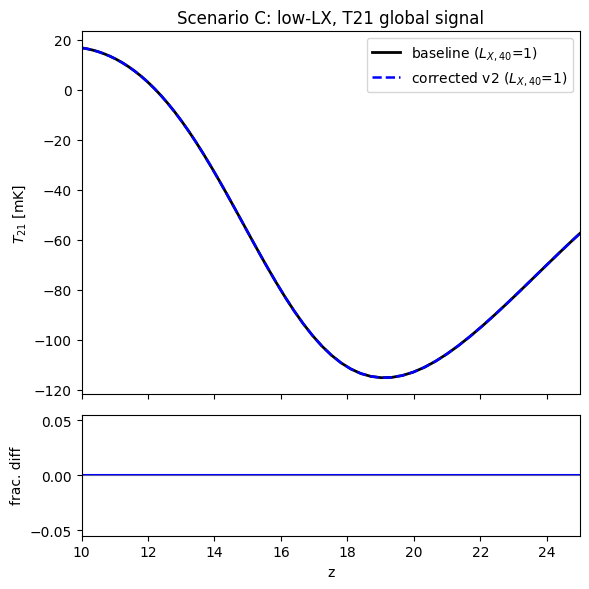

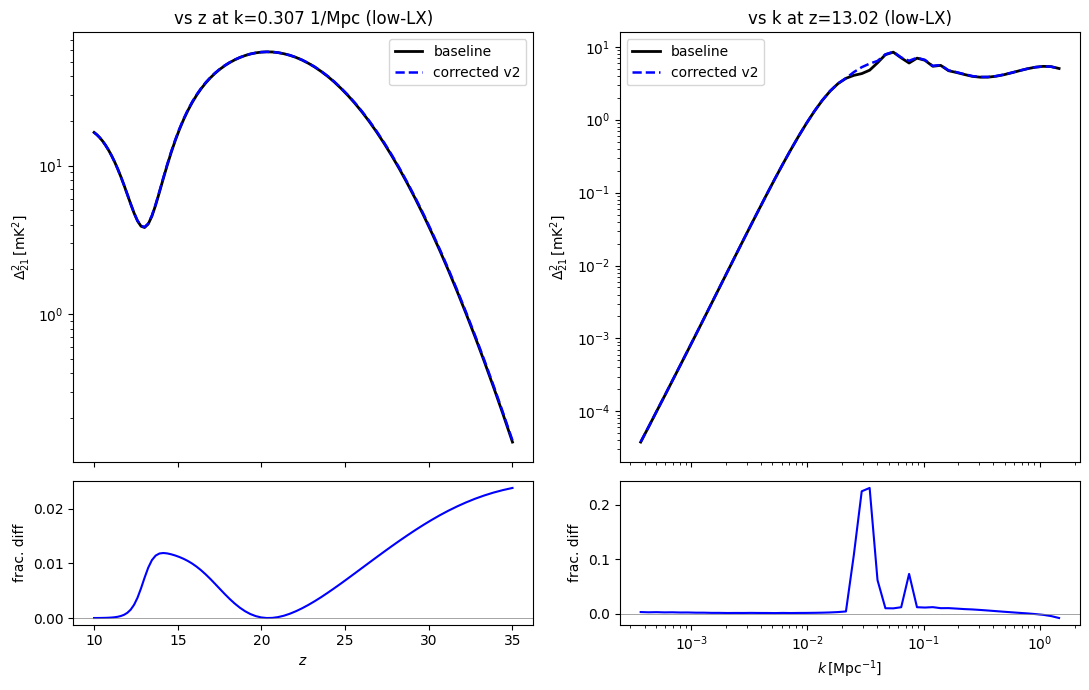

In [11]:
_, _, Coeff_base_C, PS21_base_C = run_pipeline(
    zeus21.cosmo_wrapper, zeus21.Power_Spectra,
    USE_POPIII=True, USE_RELATIVE_VELOCITIES=True, L40_xray=1.0,
)
_, _, Coeff_v2_C, PS21_v2_C = run_pipeline(
    cosmology_v2.cosmo_wrapper, correlations_v2.Power_Spectra,
    USE_POPIII=True, USE_RELATIVE_VELOCITIES=True, L40_xray=1.0,
)
zlist_C = Coeff_base_C.zintegral
klist_C = PS21_base_C.klist_PS

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True, gridspec_kw={'height_ratios':[3,1]})
ax1.plot(zlist_C, Coeff_base_C.T21avg, 'k',  lw=2.0, label='baseline ($L_{X,40}$=1)')
ax1.plot(zlist_C, Coeff_v2_C.T21avg,   'b--', lw=1.8, label='corrected v2 ($L_{X,40}$=1)')
ax1.set_ylabel(r'$T_{21}$ [mK]'); ax1.legend(); ax1.set_xlim([10, 25])
ax1.set_title('Scenario C: low-LX, T21 global signal')
denom = np.where(np.abs(Coeff_base_C.T21avg) > 1e-12, Coeff_base_C.T21avg, np.nan)
ax2.plot(zlist_C, (Coeff_v2_C.T21avg - Coeff_base_C.T21avg) / denom, 'b')
ax2.axhline(0, color='gray', lw=0.5)
ax2.set_ylabel('frac. diff'); ax2.set_xlabel(r'z')
plt.tight_layout(); plt.show()

_ikC = int(np.argmin(np.abs(klist_C - 0.3)))
_izC = int(np.argmin(np.abs(zlist_C - 13.0)))
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex='col', gridspec_kw={'height_ratios':[3,1]})
ax = axes[0,0]
ax.semilogy(zlist_C, PS21_base_C.Deltasq_T21[:, _ikC], 'k',  lw=2.0, label='baseline')
ax.semilogy(zlist_C, PS21_v2_C.Deltasq_T21[:, _ikC],   'b--', lw=1.8, label='corrected v2')
ax.set_ylabel(r'$\Delta^2_{21}\,[{\rm mK}^2]$'); ax.legend(); ax.set_title(f'vs z at k={klist_C[_ikC]:.3g} 1/Mpc (low-LX)')
ax2 = axes[1,0]
denom = PS21_base_C.Deltasq_T21[:, _ikC]
ax2.plot(zlist_C, (PS21_v2_C.Deltasq_T21[:, _ikC] - denom) / denom, 'b')
ax2.axhline(0, color='gray', lw=0.5); ax2.set_xlabel(r'$z$'); ax2.set_ylabel('frac. diff')
ax = axes[0,1]
ax.loglog(klist_C, PS21_base_C.Deltasq_T21[_izC], 'k',  lw=2.0, label='baseline')
ax.loglog(klist_C, PS21_v2_C.Deltasq_T21[_izC],   'b--', lw=1.8, label='corrected v2')
ax.set_ylabel(r'$\Delta^2_{21}\,[{\rm mK}^2]$'); ax.legend(); ax.set_title(f'vs k at z={zlist_C[_izC]:.2f} (low-LX)')
ax2 = axes[1,1]
denom = PS21_base_C.Deltasq_T21[_izC]
ax2.semilogx(klist_C, (PS21_v2_C.Deltasq_T21[_izC] - denom) / denom, 'b')
ax2.axhline(0, color='gray', lw=0.5); ax2.set_xlabel(r'$k\,[{\rm Mpc}^{-1}]$'); ax2.set_ylabel('frac. diff')
plt.tight_layout(); plt.show()

## Summary of the correction

- `cosmology_v2.runclass` builds two eta power spectra: `P_etapar` (integrand `6*(psi0+psi2)**2`) and `P_etaperp` (integrand `6*(psi0-psi2/2)**2`).
- `correlations_v2.Correlations` carries `_PkEtaParCF`/`_PkEtaPerpCF` and `xiEtaPar_RR_CF`/`xiEtaPerp_RR_CF` instead of the single `_PkEtaCF`/`xiEta_RR_CF`.
- `correlations_v2.Power_Spectra.get_xi_Sum_2ExpEta` takes both `xiEtapar` and `xiEtaperp` and replaces each `(1 - K*xiEta)**(3/2)` factor in the four-term `xiNumerator` with `((1 - K*xiEtapar)*(1 - K*xiEtaperp)**2)**(1/2)`.
- `get_all_corrs_III` builds `corrEtaNLpar`/`corrEtaNLperp` (and their per-`ir` slices) and passes both to `get_xi_Sum_2ExpEta` at the two existing call sites.